# Caption Metircs

This notebook contains the code used to compute perplexity, visualness, and lexical density, and length of different caption types.

In [ ]:
from src.caption_metrics.perplexity import *
from src.indexing_and_formatting.image_indexing_utils import shared_subset
import numpy as np
import matplotlib.pyplot as plt
import spacy
from scipy.stats import wilcoxon, pearsonr

## Perplexity

In [ ]:
for caption_type in ['molmo', 'phi','llava', 'coco', 'pixtral', 'qwen']:

    captions = format_input_sentences(caption_type=caption_type)
    sentences = [captions[id] for id in shared_subset]

    ppls = compute_batch_perplexities(
        sentences,
        model_id="mistralai/Ministral-3-8B-Base-2512",
        batch_size=50,
    )

    save_pickle(ppls, ROOT / f"results/caption_metrics/perplexity/{caption_type}_perplexity.pkl")

Loading weights: 100%|██████████| 531/531 [00:08<00:00, 61.87it/s] 
The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
Loading weights: 100%|██████████| 531/531 [00:08<00:00, 65.41it/s] 
The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
Loading weights: 100%|██████████| 531/531 [00:08<00:00, 63.45it/s] 
The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_wor

In [4]:
for caption_type in ['coco', 'llava', 'phi', 'pixtral', 'qwen', 'molmo']:
    embs = open_pickle(ROOT / f'results/caption_metrics/perplexity/{caption_type}_perplexity.pkl')
    print(f"{caption_type.capitalize()}\t{embs.mean():.2f}\t{embs.std():.0f}")

Coco	134.14	130
Llava	38.93	23
Phi	49.64	32
Pixtral	14.76	6
Qwen	18.71	9
Molmo	13.01	5


In [5]:
coco_perpl = open_pickle(ROOT / f'results/caption_metrics/perplexity/coco_perplexity.pkl')
phi_perpl = open_pickle(ROOT / f'results/caption_metrics/perplexity/phi_perplexity.pkl')
wilcoxon(coco_perpl, phi_perpl)

WilcoxonResult(statistic=26759.0, pvalue=7.372557806608689e-114)

## Visualness Scores

In [ ]:
from src.indexing_and_formatting.image_indexing_utils import shared_subset
from nltk.tokenize import RegexpTokenizer
import numpy as np
from src.indexing_and_formatting.format_sentences import format_input_sentences
from nltk.stem import WordNetLemmatizer
import nltk
import pandas as pd
# nltk.download("wordnet")
# nltk.download("omw-1.4")

Sensorymotor norms for individual words can be found here: [https://embodiedcognitionlab.shinyapps.io/sensorimotor_norms/](https://embodiedcognitionlab.shinyapps.io/sensorimotor_norms/)

Now let's have a look at the imported norms.

In [ ]:
class VisualWordsManager:

    def __init__(self):
        self.caption_types = {'coco': 'COCO', 'llava': 'LLaVA', 'phi': 'Phi-4', 
                              'pixtral': 'Pixtral', 'qwen': 'QwenVL', 'molmo': 'Molmo'}
        self.img_indices = shared_subset
        self.visual_norms = None

    def load_captions(self, caption_type: str):
        caption_dict = format_input_sentences(caption_type=caption_type)
        caption_list = [caption_dict[id] for id in shared_subset]
        return caption_list
    
    def lemmatise_and_lowercase(self, caption: str):
        tokenizer = RegexpTokenizer(r'\w+')
        word_list = tokenizer.tokenize(caption)
        wnl = WordNetLemmatizer()
        lemmatized_word_list = [wnl.lemmatize(w.lower()) for w in word_list]
        return lemmatized_word_list

    def get_unique_words(self):
        unique_words = set()
        for caption_type in self.caption_types:
            captions = self.load_captions(caption_type)
            for caption in captions:
                word_list = self.lemmatise_and_lowercase(caption)
                for word in word_list:
                    unique_words.add(word)
        return unique_words

    def load_sensory_norms(self):
        norms = pd.read_csv(ROOT / 'data/sensory_norms/norms.csv')
        visual_norm_dict = {word.lower(): score for word,score in zip(norms['Word'], norms['Visual.mean'])}
        self.visual_norms = visual_norm_dict

    def compute_caption_visualness(self, caption: str):
        processed_caption = self.lemmatise_and_lowercase(caption)
        # getting rid of repeated words
        unique_words = list(set(processed_caption))
        if self.visual_norms == None:
            self.load_sensory_norms()
        scores = np.array([self.visual_norms[word] for word in unique_words if word in self.visual_norms])
        return scores.sum()
    
    def compute_average_caption_visualness(self, caption_type: str):
        captions = self.load_captions(caption_type)

        visualness_scores = np.array([self.compute_caption_visualness(caption) for caption in captions])
        return visualness_scores
    
    def plot_caption_visualness(self):
        cmap = plt.get_cmap('tab10')
        plt.figure(figsize=(4.5,3.5), tight_layout=True)
        for i, caption_type in enumerate(self.caption_types):
            vis_scores = self.compute_average_caption_visualness(caption_type)
            vis_score, vis_score_std = vis_scores.mean(), vis_scores.std()
            plt.bar(i, vis_score, yerr = vis_score_std, color = cmap(i), label = caption_type.capitalize(), alpha=0.6)
            print(f"{caption_type.capitalize()}\t{vis_score:.2f}\t{vis_score_std:.0f}")

        plt.xticks(np.arange(len(self.caption_types)), [self.caption_types[k] for k in self.caption_types],rotation=30)
        plt.ylabel("Average visualness")
        plt.xlabel("Caption type")
        plt.grid(visible=True, axis='y')
        plt.show()
        


Coco	27.94	7
Llava	36.47	8
Phi	29.44	6
Pixtral	74.03	12
Qwen	69.75	16
Molmo	92.57	18


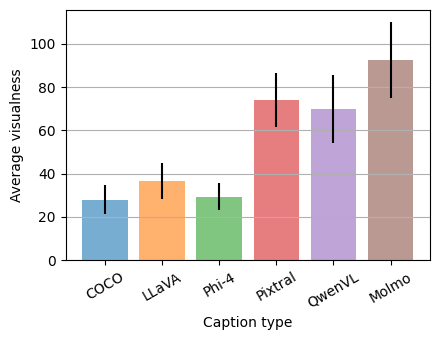

In [9]:
vwm = VisualWordsManager()
vwm.plot_caption_visualness()

In [9]:
vwm = VisualWordsManager()
for caption_type in vwm.caption_types:
    vis_score = vwm.compute_average_caption_visualness(caption_type)
    print(f"{caption_type.capitalize()}\t{vis_score:.2f}")

Molmo	92.57
Phi	29.44
Coco	27.94
Pixtral	74.03
Qwen	69.75
Llava	36.47


Note that 299 words could not be mapped to a norm, which is about 15% of the _unique_ words.

## Lexical density

In [ ]:
class LexicalDensity:

    def __init__(self):
        self.caption_types = {'coco': 'COCO', 'llava': 'LLaVA', 'phi': 'Phi-4', 
                              'pixtral': 'Pixtral', 'qwen': 'QwenVL', 'molmo': 'Molmo'}
        self.img_indices = shared_subset
        self.nlp = spacy.load("en_core_web_sm")
        self.poss = {'all': {"NOUN", "VERB", "ADJ", "ADV", "PROPN"}, 'nouns': {"NOUN", "PROPN"}, 
                        'adjectives': {"ADJ"}, 'verbs': {"VERB"}}


    def is_pos(self, token, pos: str) -> bool:
        LEXICAL_POS = self.poss[pos]

        if token.pos_ not in LEXICAL_POS:
            return False
        # Exclude auxiliaries (dep label: aux, auxpass)
        if token.dep_ in {"aux", "auxpass"}:
            return False
        return True

   
    def load_captions(self, caption_type: str):
        caption_dict = format_input_sentences(caption_type=caption_type)
        caption_list = [caption_dict[id] for id in shared_subset]
        return caption_list


    def lexical_density(self, sentence: str, pos:str) -> int:
        """
        Calculate the lexical density of a sentence using spaCy POS tagging.

        Lexical density = (number of lexical words / total words) * 100

        Lexical words: nouns, proper nouns, main verbs, adjectives, adverbs.
        Function words: everything else (determiners, pronouns, prepositions,
                        conjunctions, auxiliaries, particles, punctuation, etc.)
        """
        doc = self.nlp(sentence)

        # Only consider actual word tokens (exclude punctuation & spaces)
        tokens = [t for t in doc if not t.is_punct and not t.is_space]

        if not tokens:
            return {"error": "No words found in the input."}

        lexical_tokens   = [t for t in tokens if self.is_pos(t, pos)]
        # function_tokens  = [t for t in tokens if not self.is_lexical(t)]
        density = (len(lexical_tokens) / len(tokens)) * 100

        return density
    
    def compute_average_density(self, caption_type: str, pos:str):
        captions = self.load_captions(caption_type)

        densities = np.array([self.lexical_density(caption, pos) for caption in captions])
        return densities.mean(), densities.std()
    
    def plot_caption_density(self, pos: str):
        cmap = plt.get_cmap('tab10')
        plt.figure(figsize=(4.5,3.5), tight_layout=True)
        for i, caption_type in enumerate(self.caption_types):
            density, density_std = self.compute_average_density(caption_type, pos)
            print(f"{caption_type.capitalize()}\t{density:.2f}\t{density_std:.0f}")
            plt.bar(i, density, yerr = density_std, color = cmap(i), label = caption_type.capitalize(), alpha=0.6)

        plt.xticks(np.arange(len(self.caption_types)), [self.caption_types[k] for k in self.caption_types],rotation=30)
        plt.ylabel("Lexical density (%)")
        plt.xlabel("Caption type")
        plt.grid(visible=True, axis='y')
        plt.show()



Coco	54.27	10
Llava	51.68	7
Phi	48.13	7
Pixtral	55.04	6
Qwen	57.61	6
Molmo	57.27	5


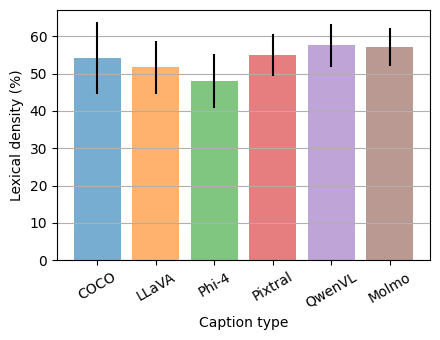

In [10]:
ld = LexicalDensity()
ld.plot_caption_density('all')

Coco	7.38	8
Llava	8.44	8
Phi	5.61	7
Pixtral	12.18	6
Qwen	12.37	6
Molmo	15.66	5


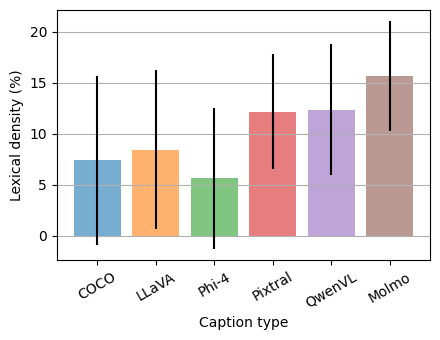

In [11]:
ld.plot_caption_density('adjectives')

Coco	35.18	9
Llava	34.53	8
Phi	33.87	7
Pixtral	30.43	5
Qwen	32.45	6
Molmo	30.96	5


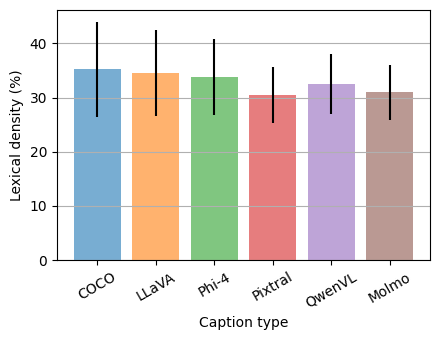

In [12]:
ld.plot_caption_density('nouns')

Coco	10.23	7
Llava	8.16	5
Phi	8.09	6
Pixtral	10.76	4
Qwen	11.14	4
Molmo	9.53	3


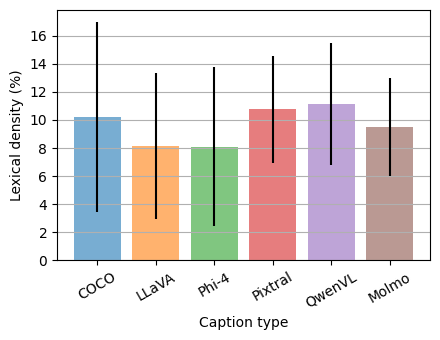

In [13]:
ld.plot_caption_density('verbs')


## Caption length

Coco	10.50	2
Llava	13.10	3
Phi	10.89	2
Pixtral	30.57	5
Qwen	27.46	7
Molmo	36.95	8


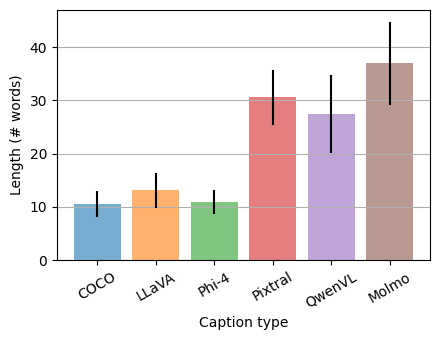

In [12]:
class CaptionLength:

    def __init__(self):
        self.caption_types = {'coco': 'COCO', 'llava': 'LLaVA', 'phi': 'Phi-4', 
                              'pixtral': 'Pixtral', 'qwen': 'QwenVL', 'molmo': 'Molmo'}
        self.img_indices = shared_subset
        
    def load_captions(self, caption_type: str):
        caption_dict = format_input_sentences(caption_type=caption_type)
        caption_list = [caption_dict[id] for id in shared_subset]
        return caption_list

    def compute_number_of_words(self, caption: str):

        word_count = len(caption.split())

        return word_count

    def compute_avg_n_words(self, caption_type):
        captions = self.load_captions(caption_type)
        n_words = np.array([self.compute_number_of_words(caption) for caption in captions])

        # return n_words.mean(), n_words.std()
        return n_words

    def plot_caption_length(self):
        cmap = plt.get_cmap('tab10')
        plt.figure(figsize=(4.5,3.5), tight_layout=True)
        for i, caption_type in enumerate(self.caption_types):
            n_words = self.compute_avg_n_words(caption_type)
            n_words_mean, n_words_std = n_words.mean(), n_words.std()
            print(f"{caption_type.capitalize()}\t{n_words_mean:.2f}\t{n_words_std:.0f}")
            plt.bar(i, n_words_mean, yerr = n_words_std, color = cmap(i), label = caption_type.capitalize(), alpha=0.6)

        plt.xticks(np.arange(len(self.caption_types)), [self.caption_types[k] for k in self.caption_types],rotation=30)
        plt.ylabel("Length (# words)")
        plt.xlabel("Caption type")
        plt.grid(visible=True, axis='y')
        plt.show()

cl = CaptionLength()
cl.plot_caption_length()



In [16]:
cl = CaptionLength()
vwm = VisualWordsManager()
for caption_type in vwm.caption_types:
    vis_scores = vwm.compute_average_caption_visualness(caption_type)
    n_words = cl.compute_avg_n_words(caption_type)
    corr, pval = pearsonr(vis_scores, n_words)
    print(f"{caption_type} r={corr:.2f} p={pval:.4f}")

coco r=0.77 p=0.0000
llava r=0.88 p=0.0000
phi r=0.84 p=0.0000
pixtral r=0.77 p=0.0000
qwen r=0.88 p=0.0000
molmo r=0.88 p=0.0000


In [7]:
cap_lengths = np.array([10.5, 13.10, 10.89, 30.57, 27.46, 36.95])
cap_visualness = np.array([27.94, 36.47, 29.44, 74.03, 69.75, 92.57])
pearsonr(cap_lengths, cap_visualness)

PearsonRResult(statistic=0.9986158067541671, pvalue=2.8726603618539428e-06)